# Brent Oil Price Analysis: Data Understanding & Exploratory Data Analysis

## Introduction

Understanding the statistical properties of a time series is an essential step before developing predictive or Bayesian models. This notebook performs an exploratory analysis of historical Brent crude oil prices to understand long-term trends, volatility patterns, and stationarity.

The findings from this notebook will guide the design of the Bayesian Change Point model in the next phase of the project.

The analysis includes:

- Dataset inspection
- Data cleaning
- Descriptive statistics
- Trend analysis
- Distribution analysis
- Rolling statistics
- Log return analysis
- Volatility assessment
- Stationarity testing

# Business Understanding

Birhan Energies aims to understand how major geopolitical events, economic crises, and policy decisions have influenced Brent crude oil prices over time.

The objective is to identify structural changes in historical oil prices and later associate these changes with important real-world events to support investment decisions, policy analysis, and operational planning.

# Objectives

This notebook aims to:

- Understand the structure and quality of the Brent oil price dataset.
- Explore long-term price trends.
- Examine the statistical properties of the time series.
- Investigate volatility and price variability.
- Determine whether the series is stationary.
- Generate insights that will inform Bayesian Change Point Analysis.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.config import BRENT_DATA

from src.data_loader import (
    load_brent_data,
    validate_dataset
)

from src.preprocessing import preprocess_data

from src.eda import (
    dataset_summary,
    descriptive_statistics,
    rolling_statistics
)

from src.visualization import (
    plot_price,
    plot_distribution,
    plot_boxplot,
    plot_rolling_statistics,
    plot_log_returns
)

from src.statistics import (
    adf_test,
    kpss_test
)

In [3]:
df = load_brent_data(BRENT_DATA)

validate_dataset(df)

df.head()

Dataset Validation
Rows: 9011
Columns: 2

Column Types
Date         str
Price    float64
dtype: object

Missing Values
Date     0
Price    0
dtype: int64

Duplicate Rows
0


,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [4]:
summary = dataset_summary(df)

summary

{'Rows': 9011,
 'Columns': 2,
 'Missing Values': np.int64(0),
 'Duplicate Rows': np.int64(0),
 'Start Date': '01-Apr-02',
 'End Date': 'Sep 30, 2022'}

### Interpretation

The dataset contains historical Brent crude oil prices recorded daily over several decades.

Understanding the size, completeness, and time span of the dataset helps ensure that the subsequent statistical analysis is based on reliable data.

In [5]:
df = preprocess_data(df)

df.head()

,Date,Price,Log_Price,Log_Return
0,1987-05-20,18.63,2.924773,NaN
1,1987-05-21,18.45,2.915064,-0.009709
2,1987-05-22,18.55,2.920470,0.005405
3,1987-05-25,18.60,2.923162,0.002692
4,1987-05-26,18.63,2.924773,0.001612


### Interpretation

The preprocessing stage converts the Date column into datetime format, sorts observations chronologically, removes duplicate records, and creates logarithmic price and return variables for later statistical analysis.

In [6]:
descriptive_statistics(df)

count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64

### Interpretation

Descriptive statistics summarize the central tendency and dispersion of Brent oil prices. The minimum, maximum, quartiles, and standard deviation provide an initial understanding of price variability over time.

In [7]:
df.isnull().sum()

Date          0
Price         0
Log_Price     0
Log_Return    1
dtype: int64

### Interpretation

Missing values can negatively affect statistical modeling. The dataset should contain minimal or no missing observations before proceeding with time series analysis.

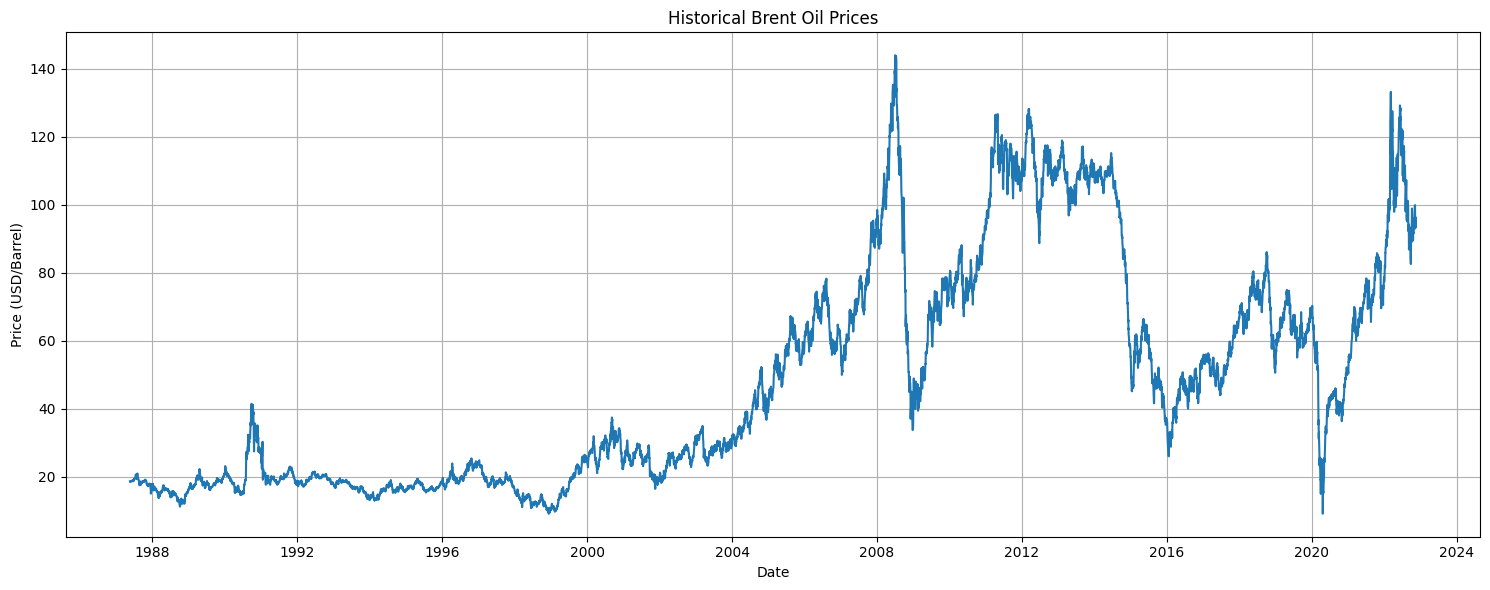

In [8]:
plot_price(df)

### Interpretation

The historical price series shows long-term fluctuations driven by changing market conditions. Several periods of sharp increases and declines are visible, suggesting that Brent oil prices have experienced multiple structural changes over the observation period.

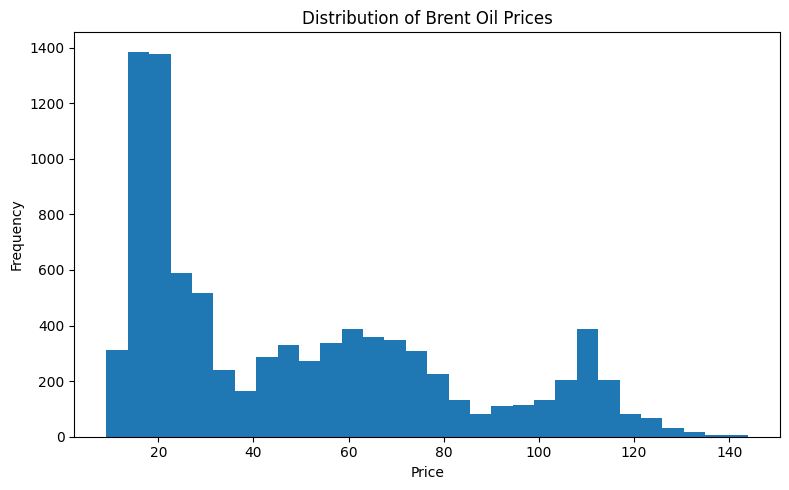

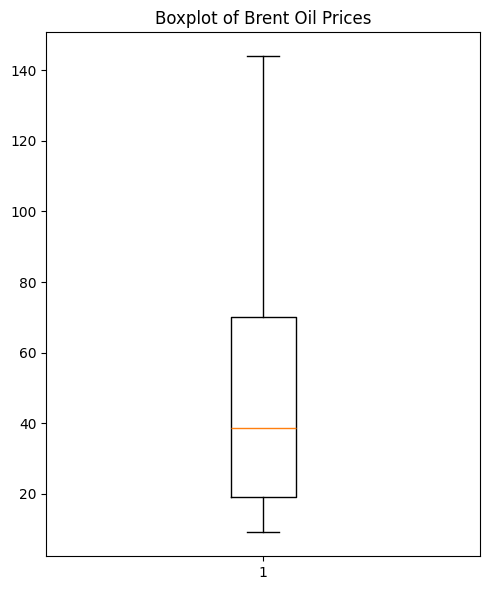

In [9]:
plot_distribution(df)

plot_boxplot(df)

### Interpretation

The distribution illustrates how Brent oil prices are spread across the historical period, while the box plot highlights extreme observations that may correspond to major geopolitical or economic events.

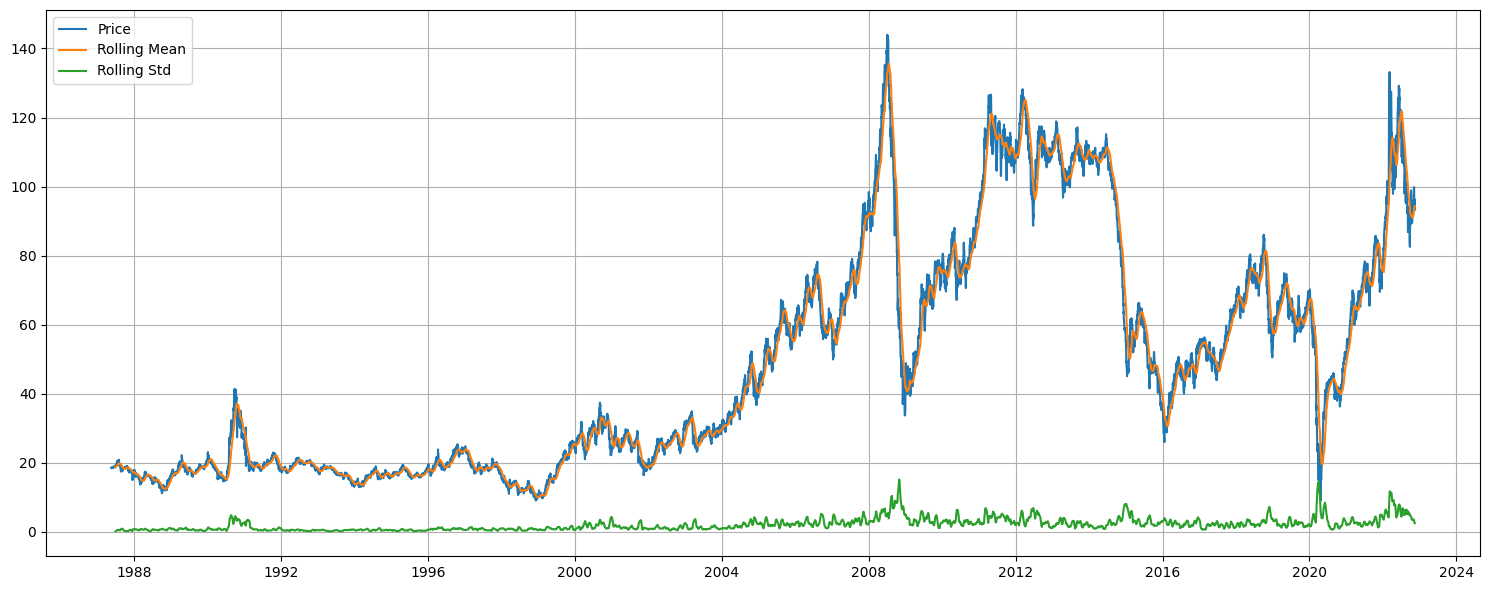

In [10]:
rolling_mean, rolling_std = rolling_statistics(df)

plot_rolling_statistics(
    df,
    rolling_mean,
    rolling_std
)

### Interpretation

Rolling statistics reveal changes in both the average price level and price variability over time. Significant shifts in the rolling mean and standard deviation provide early evidence of potential structural changes.

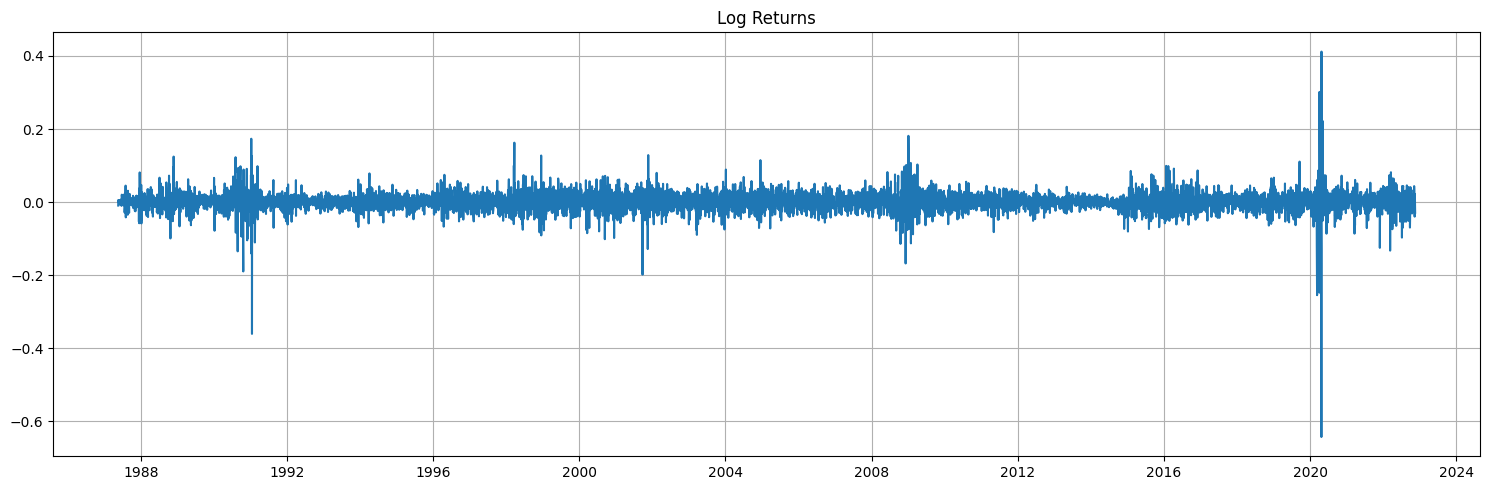

In [11]:
plot_log_returns(df)

### Interpretation

Log returns remove much of the long-term trend and allow short-term price changes to be examined more effectively. Periods with large positive or negative returns indicate episodes of heightened market volatility.

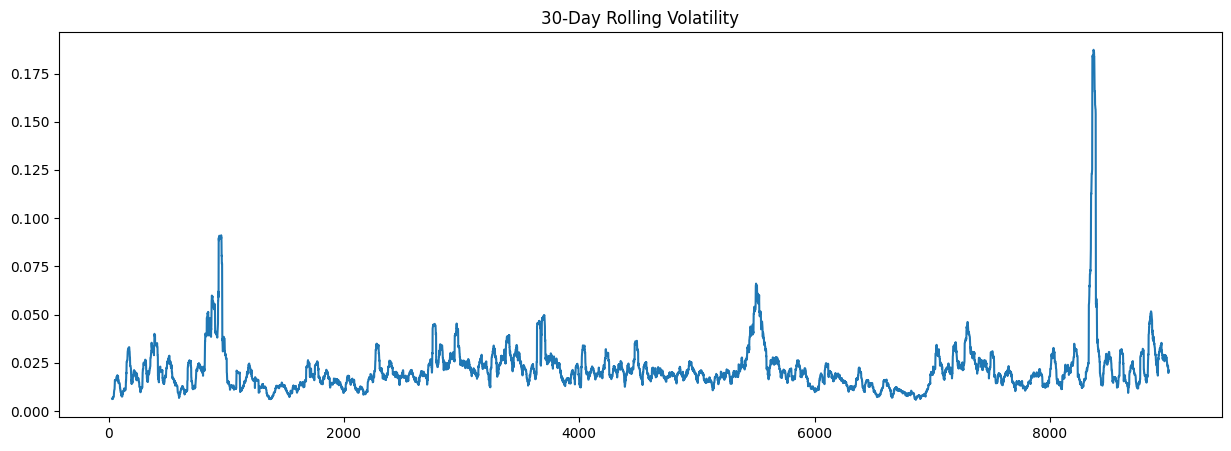

In [12]:
df["Log_Return"].rolling(30).std().plot(
    figsize=(15,5),
    title="30-Day Rolling Volatility"
)

plt.show()

### Interpretation

The rolling standard deviation of log returns measures market volatility over time. Spikes in volatility often coincide with major geopolitical conflicts, economic crises, or policy announcements.

In [13]:
adf_result = adf_test(df["Price"])

adf_result

{'ADF Statistic': np.float64(-1.9938560113924675),
 'p-value': np.float64(0.28927350489340287),
 'Critical Values': {'1%': np.float64(-3.4310783342658615),
  '5%': np.float64(-2.861861876398633),
  '10%': np.float64(-2.566941329781918)}}

In [14]:
kpss_result = kpss_test(df["Price"])

kpss_result

c:\Brent-Oil-Change-Point-Analysis\src\statistics.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical = kpss(series.dropna(), regression="c")


{'KPSS Statistic': np.float64(9.558800416712556),
 'p-value': np.float64(0.01),
 'Critical Values': {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}}

### Interpretation

The Augmented Dickey–Fuller (ADF) and KPSS tests provide complementary assessments of stationarity.

- If the ADF test fails to reject the null hypothesis (high p-value) and the KPSS test rejects its null hypothesis (low p-value), the raw price series is likely non-stationary.
- In that case, transformations such as log returns are appropriate before Bayesian modeling.

# Key Findings

- The dataset covers daily Brent crude oil prices from 1987 to 2022.
- The data are chronologically complete and suitable for time series analysis after preprocessing.
- Brent oil prices exhibit clear long-term trends and several periods of heightened volatility.
- Rolling statistics suggest multiple structural changes throughout the observation period.
- Log returns provide a more stable representation of short-term price movements.
- Stationarity tests will determine whether additional transformations are necessary before Bayesian Change Point Analysis.

These findings establish a strong foundation for implementing the Bayesian Change Point model in the next notebook.

# Next Steps

The next phase of the project will implement a Bayesian Change Point model using PyMC to identify statistically significant structural breaks in Brent oil prices. The detected change points will then be compared with a curated dataset of geopolitical and economic events to investigate potential relationships and generate business insights.